# **EDA**

**Exploratory Data Analysis , The process pf analyzing and visualizing the dataset to identify patterns, relationships before building ml models**

### **Load processed data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sales_df = pd.read_csv(
    "../data/processed/valid_sales.csv",
    dtype={"Invoice": "string"},
    parse_dates=["InvoiceDate"]
)

daily_sales = pd.read_csv(
    "../data/processed/daily_sales.csv",
    parse_dates=["Date"]
)

In [2]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue,Year,Month,Day,DayOfWeek,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,1,1,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,1,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,1,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,1,1,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,1,1,7,False


### **Daily revenue**

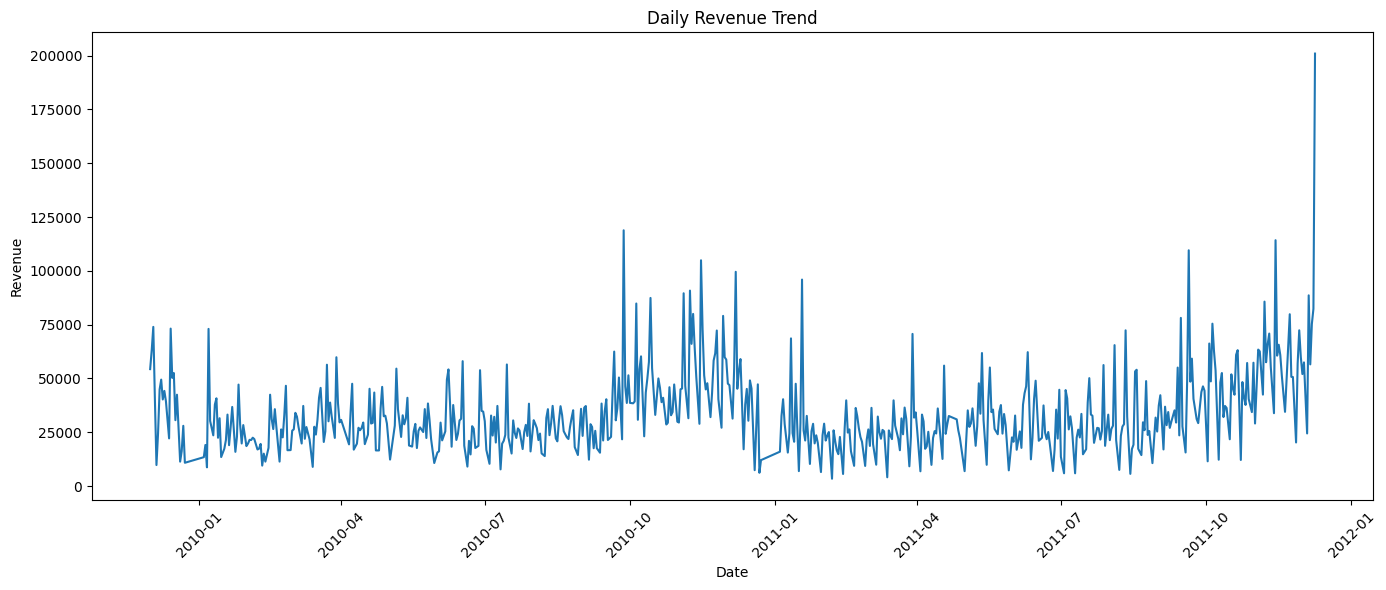

In [3]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Monthly Revenue**

In [4]:
monthly_sales = (
    sales_df
        .set_index("InvoiceDate")
        .resample("ME")["Revenue"]
        .sum()
        .reset_index()
)

monthly_sales["Month"] = monthly_sales["InvoiceDate"].dt.strftime("%Y-%m")

In [5]:
print(monthly_sales)

   InvoiceDate      Revenue    Month
0   2009-12-31   822483.950  2009-12
1   2010-01-31   651155.112  2010-01
2   2010-02-28   551504.726  2010-02
3   2010-03-31   830915.261  2010-03
4   2010-04-30   678875.252  2010-04
5   2010-05-31   657705.500  2010-05
6   2010-06-30   749537.310  2010-06
7   2010-07-31   648810.270  2010-07
8   2010-08-31   695251.910  2010-08
9   2010-09-30   921696.991  2010-09
10  2010-10-31  1161902.220  2010-10
11  2010-11-30  1464293.142  2010-11
12  2010-12-31   821452.730  2010-12
13  2011-01-31   689811.610  2011-01
14  2011-02-28   522545.560  2011-02
15  2011-03-31   716215.260  2011-03
16  2011-04-30   536968.491  2011-04
17  2011-05-31   769296.610  2011-05
18  2011-06-30   760547.010  2011-06
19  2011-07-31   718076.121  2011-07
20  2011-08-31   757841.380  2011-08
21  2011-09-30  1056435.192  2011-09
22  2011-10-31  1151263.730  2011-10
23  2011-11-30  1503866.780  2011-11
24  2011-12-31   637808.330  2011-12


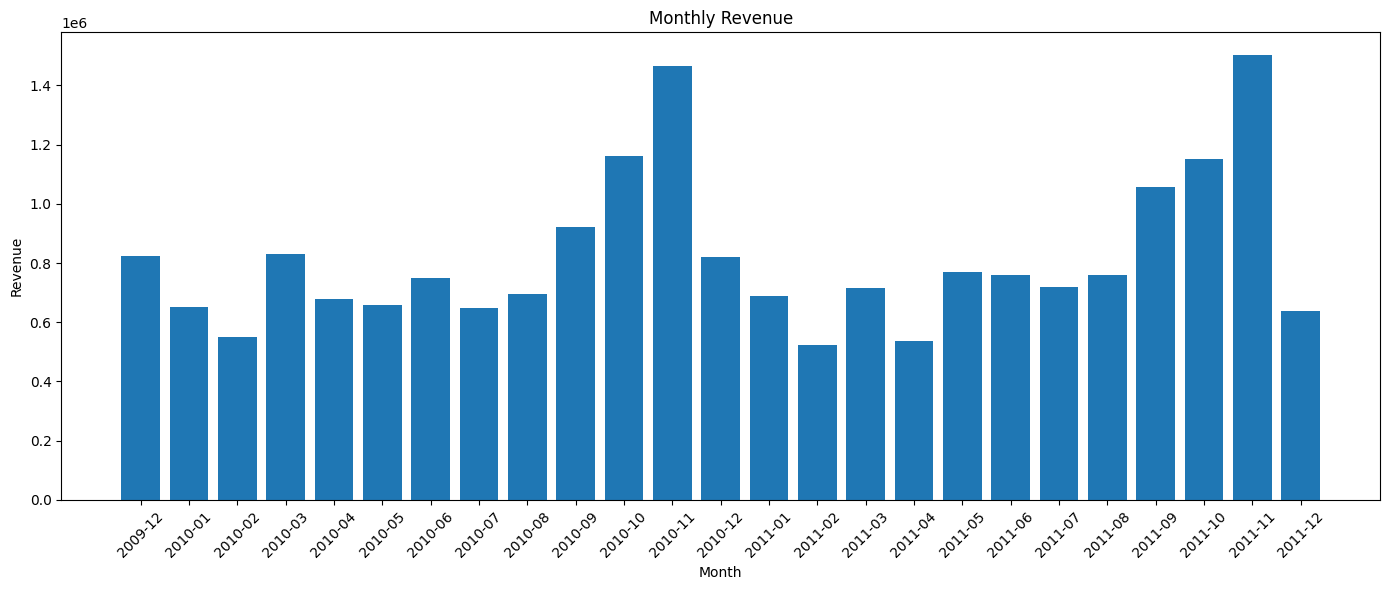

In [6]:
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_sales["Month"],
    monthly_sales["Revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Top Products by revenue**

In [7]:
top_products = (
    sales_df
        .groupby("Description")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

top_products

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64